# Getting started with MemsArrayDB objects

The `MemsArrayDB` class allows getting signals from MemsArray saved in a remote database 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros_tools.log import log
from megamicros.core.db import MemsArrayDB

log.setLevel( "INFO" )

# Set database access credentials
DBHOST = 'http://dbchantier.bimea.tech/'
LOGIN = 'ailab'
EMAIL = 'bruno.gas@biimea.com'
PASSWORD = '#T;uZnQ5UJ_JC~&'

## Starting with simple signals

One has only to specify the file identifier.

The ``MemsArrayDB`` constructor connects to the database and populates the antenna parameters with metadata received from the database. An exception is raised if connection failed.

In [5]:
# Choose the very first signal file of the database-
FILE_ID = 1239
FILE_ID = 1231          # Bips

FILE_ID = 1394
FILE_ID = 1380
FILE_ID = 1365
FILE_ID = 400

# Define the antenna
antenna = MemsArrayDB( 
    dbhost=DBHOST, login=LOGIN, email=EMAIL, password=PASSWORD, 
    file_id=FILE_ID
)

2024-06-26 14:11:01,693 [INFO]:  .Install MemsArrayDB settings
2024-06-26 14:11:01,694 [INFO]:  .Created a new antenna
2024-06-26 14:11:01,694 [INFO]:  .Install MemsArrayDB settings
2024-06-26 14:11:01,695 [INFO]:  .Try connecting on endpoint database http://dbchantier.bimea.tech//dj-rest-auth/login/...
2024-06-26 14:11:02,044 [INFO]:  .Got HTTP 200 status code from server
2024-06-26 14:11:02,045 [INFO]:  .Received CSRF token: tNes9XSkNROqFmya4iDVNBfwWNX2zpi1. Update session with
2024-06-26 14:11:02,045 [INFO]:  .Received session id: bw0zf61p9ugbyg4xaczy3cbozi92kxpo
2024-06-26 14:11:02,045 [INFO]:  .Successfully connected on http://dbchantier.bimea.tech/
2024-06-26 14:11:02,046 [INFO]:  .Downloading metadata for object 'sourcefile' [400]...
2024-06-26 14:11:02,046 [INFO]:  .Send a database request on endpoint: http://dbchantier.bimea.tech//sourcefile/400
2024-06-26 14:11:02,089 [INFO]:  .Object sourcefile found with identifier [400] 
2024-06-26 14:11:02,090 [INFO]:  .Set 24 available M

You can get now some Meta informations regarding the file

In [6]:
print( f"Sampling frequency: {antenna.sampling_frequency}Hz" )
print( f"Available MEMs number: {antenna.available_mems_number}" )
print( f"Whether counter is available or not: {antenna.counter}" )
print( f"File duration: {antenna.file_duration} s")
print( f"File date: {antenna.meta['datetime']}")
print( f"File all meta data: {antenna.meta}")

Sampling frequency: 25000.0Hz
Available MEMs number: 24
Whether counter is available or not: True
File duration: 900 s
File date: 2023-07-13T09:21:29Z
File all meta data: {'id': 400, 'url': 'http://dbchantier.bimea.tech/sourcefile/400/', 'filename': 'muh5-20230713-092129.h5', 'type': 4, 'datetime': '2023-07-13T09:21:29Z', 'duration': 900, 'directory': 'http://dbchantier.bimea.tech/directory/1/', 'size': 2251344312, 'integrity': True, 'contexts': [], 'labels': [], 'tags': [], 'comment': None, 'info': {'ctime': '2023-08-18 23:37:20.054411', 'mtime': '2023-08-18 23:37:20.054411', 'size': 2251344312, 'sampling_frequency': 25000.0, 'timestamp': 1689240089.0, 'duration': 900.0, 'date': '2023-07-13 09:21:29.000000', 'channels_number': 25, 'analogs_number': 0, 'mems_number': 24, 'dataset_number': 900, 'dataset_duration': 1, 'dataset_length': 25000, 'compression': 0, 'counter': 1, 'counter_skip': 0, 'analogs': [], 'mems': [0, 1, 2, 3, 4, 5, 6, 7, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 

## Getting and plotting some MEMs signals

You can select some MEMs you would like to plot and get signals on a given range time (10 seconds in this example)

In [7]:
# Run antenna
antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    start = 0,
    duration=2,
    counter_skip = True,
    datatype='float32',
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"exit from loop. Signal shape is: {np.shape( signals )}" )

2024-06-26 14:11:16,299 [INFO]:  .Starting run execution
2024-06-26 14:11:16,300 [INFO]:  .Install MemsArray settings
2024-06-26 14:11:16,303 [INFO]:  .7 MEMs were activated among 0 to 23 available MEMs
2024-06-26 14:11:16,303 [INFO]:  .Set datatype to float32 
2024-06-26 14:11:16,304 [INFO]:  .Install MemsArrayDB settings
2024-06-26 14:11:16,305 [INFO]:  .Pre-execution checks for MemsArray.run()
2024-06-26 14:11:16,306 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2024-06-26 14:11:16,307 [INFO]:  .Perform a 2s run loop
2024-06-26 14:11:16,308 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2024-06-26 14:11:16,309 [INFO]:  .Sampling frequency: 25000.0 Hz
2024-06-26 14:11:16,309 [INFO]:  .Active MEMs: [0, 1, 2, 3, 4, 5, 6]
2024-06-26 14:11:16,310 [INFO]:  .Active analogic channels: []
2024-06-26 14:11:16,311 [INFO]:  .Whether counter is active: True
2024-06-26 14:11:16,311 [INFO]:  .Skipping counter: True
2024-06-26 14:11:16,312 [INFO]:  .Requesting data in range [0s

exit from loop. Signal shape is: (50001, 7)


Here is the ploting program

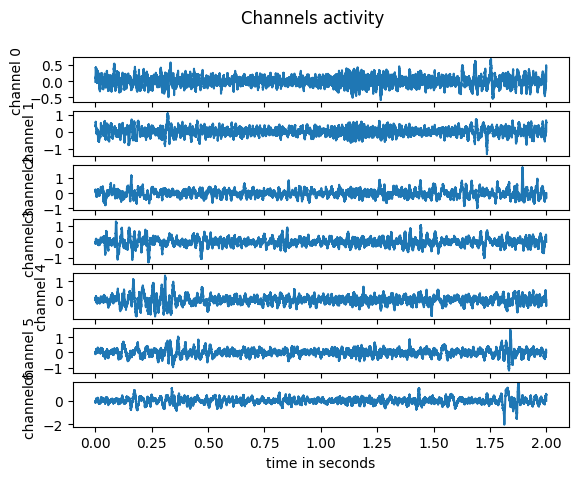

In [8]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wave file
TO BE REVIEWED !!!

In [ ]:
import wave

WAV_FILENAME = 'titi.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [5, 6],
    duration=20,
    counter_skip = True,
    datatype='int32'
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='C' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

## Hearing signal with *pyaudio* library

In [30]:
import pyaudio

FRAME_LENGTH = 256

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[0, 1],
    start = 120,
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    signal_q_size = 0,
    datatype='int32'
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ) * antenna.sensibility )

    # write into audio stream
    stream.write( data.tobytes( order='C'), num_frames=FRAME_LENGTH )
    transfers_counter += 1


# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()

print( f"Exit from loop with {transfers_counter} transfers" )

2023-11-30 15:29:50,951 [INFO]:  .Starting run execution
2023-11-30 15:29:50,953 [INFO]:  .Install MemsArray settings
2023-11-30 15:29:50,954 [INFO]:  .2 MEMs were activated among 0 to 23 available MEMs
2023-11-30 15:29:50,954 [INFO]:  .Set datatype to int32 
2023-11-30 15:29:50,954 [INFO]:  .Install MemsArrayDB settings
2023-11-30 15:29:50,955 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-30 15:29:50,955 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-11-30 15:29:50,955 [INFO]:  .Perform a 10s run loop
2023-11-30 15:29:50,955 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-11-30 15:29:50,956 [INFO]:  .Sampling frequency: 25000.0 Hz
2023-11-30 15:29:50,956 [INFO]:  .Active MEMs: [0, 1]
2023-11-30 15:29:50,956 [INFO]:  .Active analogic channels: []
2023-11-30 15:29:50,957 [INFO]:  .Whether counter is active: True
2023-11-30 15:29:50,957 [INFO]:  .Skipping counter: True
2023-11-30 15:29:50,957 [INFO]:  .Requesting data in range [120s, 130s]
2023-1

Exit from loop with 977 transfers


## Getting labelized signals

You can obtain labelled signals from the base by specifying the necessary parameters: 
* The label identifier
* The file identifier where labeled signals are
* The sequence identifier 

In [ ]:
# choose label, file and sequence in file:
LABEL_ID = 18
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0  

# Define the antenna
antenna = MemsArrayDB( 
    dbhost=DBHOST, login=LOGIN, email=EMAIL, password=PASSWORD, 
    label_id=LABEL_ID, file_id=FILE_ID, sequence_id=SEQUENCE_ID
)

## Plotting

In [ ]:
# 2 seconds run, getting signals from MEMs 1 and 2

antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
    counter_skip = True,
    datatype='float32'
)

signals = np.ndarray( (0, antenna.channels_number ) )

for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

print( f"exit from loop, signal shape is: {np.shape( signals )}" )

# waiting for the end of the running thread is mandatory
antenna.wait()

# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()



## Hearing

In [ ]:
import pyaudio

FRAME_LENGTH = 256

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[0, 1],
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    datatype='int32'
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ) * antenna.sensibility )

    # write into audio stream
    stream.write( data.tobytes( order='C'), num_frames=FRAME_LENGTH )
    transfers_counter += 1


# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()

print( f"Exit from loop with {transfers_counter} transfers" )

## Getting counter 

You just have to set `counter_skip` to `False`

In [ ]:
antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
    counter_skip = False,
    datatype='float32'
)

counter = ( signals[:,0]/antenna.sensibility ).tobytes()
counter = np.frombuffer( counter, dtype=np.int32 )

print( counter )

## Getting samples

In [4]:
signals = antenna.get(
    mems = [0, 1, 2, 3, 4, 5, 6],
    start_sample = 0,
    stop_sample = 256,
    datatype='int32'
)

print( f"signals={signals}" )

2023-11-16 15:16:30,357 [INFO]:  .Install MemsArray settings
2023-11-16 15:16:30,360 [INFO]:  .7 MEMs were activated among 0 to 23 available MEMs
2023-11-16 15:16:30,360 [INFO]:  .Set datatype to int32 
2023-11-16 15:16:30,361 [INFO]:  .Install MemsArrayDB settings
2023-11-16 15:16:30,361 [INFO]:  .Pre-execution checks for MemsArray.get()
2023-11-16 15:16:30,362 [INFO]:  .Counter skipping not set -> set to False
2023-11-16 15:16:30,363 [INFO]:  .Try connecting on endpoint database http://dbchantier.biimea.io//dj-rest-auth/login/...
2023-11-16 15:16:30,811 [INFO]:  .Got HTTP 200 status code from server
2023-11-16 15:16:30,812 [INFO]:  .Received CSRF token: JMGenoci7YvP1NNkMMa0qhJB8HMNFW4z. Update session with
2023-11-16 15:16:30,812 [INFO]:  .Received session id: exr1i6qm3knl04tpz6k25dyresadcrax
2023-11-16 15:16:30,813 [INFO]:  .Successfully connected on http://dbchantier.biimea.io/
2023-11-16 15:16:30,814 [INFO]:  .Downloading metadata for object 'sourcefile' [1231]...
2023-11-16 15:16

Got mete: {'id': 1231, 'url': 'http://dbchantier.biimea.io/sourcefile/1231/', 'filename': 'muh5-20231025-162636.h5', 'type': 4, 'datetime': '2023-10-25T16:26:36Z', 'duration': 899, 'directory': 'http://dbchantier.biimea.io/directory/1/', 'size': 2248842264, 'integrity': True, 'contexts': [], 'labels': [], 'tags': [], 'comment': None, 'info': {'ctime': '2023-10-26 12:40:58.247706', 'mtime': '2023-10-26 00:14:46.991369', 'size': 2248842264, 'sampling_frequency': 25000.0, 'timestamp': 1698251196.0, 'duration': 899.0, 'date': '2023-10-25 16:26:36.000000', 'channels_number': 25, 'analogs_number': 0, 'mems_number': 24, 'dataset_number': 899, 'dataset_duration': 1, 'dataset_length': 25000, 'compression': 0, 'counter': 1, 'counter_skip': 0, 'analogs': [], 'mems': [0, 1, 2, 3, 4, 5, 6, 7, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]}, 'crdate': '2023-10-26T12:41:32.871134Z'}
signals=None


## Performing beamforming

TO DO...